<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [6]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.datasets as datasets
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

In [1]:
import os

os.environ['KAGGLE_API_TOKEN'] = "yourkey"

In [2]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [4]:
!kaggle datasets download tommykamaz/faces-dataset-small

Dataset URL: https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.99G/3.99G [00:25<00:00, 166MB/s]



In [5]:
!unzip -q faces-dataset-small.zip -d faces_dataset_small

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [66]:
def get_dataloader(image_size, batch_size):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  transform = tt.Compose([
      tt.Resize([image_size, image_size]),
      tt.CenterCrop([image_size, image_size]),
      tt.ToTensor(),
      tt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])

  dataset = datasets.ImageFolder(
      root='/content/faces_dataset_small',
      transform=transform
  )

  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=True
  )

  return dataloader

In [67]:
image_size = 64
batch_size = 128

dataloader = get_dataloader(image_size, batch_size)

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [68]:
discriminator = nn.Sequential(
    # in: 3 x 64 x 64

    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 64 x 32 x 32

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 128 x 16 x 16

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 256 x 8 x 8

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 512 x 4 x 4

    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
    # out: 1 x 1 x 1

    nn.Flatten(),
    nn.Sigmoid()).to(device)

In [69]:
latent_size = 128
generator = nn.Sequential(
    # in: latent_size x 1 x 1

    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # out: 512 x 4 x 4

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # out: 256 x 8 x 8

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # out: 128 x 16 x 16

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # out: 64 x 32 x 32

    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh()
    # out: 3 x 64 x 64
).to(device)

In [70]:
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device
discriminator = to_device(discriminator, device)
generator = to_device(generator, device)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [71]:
lr = 0.0002

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [72]:
def show_generated(n_images: int=4):
  with torch.no_grad():
    fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
    model["generator"].eval()
    fake_images = denorm(model["generator"](fixed_latent))

    fake_images = fake_images.detach().cpu().permute(0, 2, 3, 1).numpy()
    n = fake_images.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    for i in range(n):
      axes[i].imshow(fake_images[i])
      axes[i].axis('off')

    plt.show()

In [73]:
sample_dir = 'generated'
os.makedirs(sample_dir, exist_ok=True)

stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def save_samples(index, latent_tensors, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'generated-images-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    print('Saving', fake_fname)
    if show:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1, 2, 0))

In [74]:
def fit(model, criterion, epochs, lr, start_idx=1):
    model["discriminator"].train()
    model["generator"].train()
    torch.cuda.empty_cache()

    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    optimizer = {
        "discriminator": torch.optim.Adam(model["discriminator"].parameters(),
                                          lr=lr, betas=(0.5, 0.999)),
        "generator": torch.optim.Adam(model["generator"].parameters(),
                                      lr=lr, betas=(0.5, 0.999))
    }

    for epoch in range(epochs):
        loss_d_per_epoch = []
        loss_g_per_epoch = []
        real_score_per_epoch = []
        fake_score_per_epoch = []
        for real_images, _ in tqdm(dataloader):
            real_images = real_images.to(device)
            optimizer["discriminator"].zero_grad()

            real_preds = model["discriminator"](real_images)

            real_targets = torch.FloatTensor(real_images.size(0), 1).uniform_(0.95, 1.0).to(device)
            real_loss = criterion["discriminator"](real_preds, real_targets)
            cur_real_score = torch.mean(real_preds).item()

            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            fake_targets = torch.FloatTensor(fake_images.size(0), 1).uniform_(0.0, 0.05).to(device)
            fake_preds = model["discriminator"](fake_images)
            fake_loss = criterion["discriminator"](fake_preds, fake_targets)
            cur_fake_score = torch.mean(fake_preds).item()

            real_score_per_epoch.append(cur_real_score)
            fake_score_per_epoch.append(cur_fake_score)

            loss_d = real_loss + fake_loss
            loss_d.backward()
            optimizer["discriminator"].step()
            loss_d_per_epoch.append(loss_d.item())


            optimizer["generator"].zero_grad()

            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            preds = model["discriminator"](fake_images)
            targets = torch.FloatTensor(fake_images.size(0), 1).uniform_(0.95, 1.0).to(device)
            loss_g = criterion["generator"](preds, targets)

            loss_g.backward()
            optimizer["generator"].step()
            loss_g_per_epoch.append(loss_g.item())

        losses_g.append(np.mean(loss_g_per_epoch))
        losses_d.append(np.mean(loss_d_per_epoch))
        real_scores.append(np.mean(real_score_per_epoch))
        fake_scores.append(np.mean(fake_score_per_epoch))

        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs,
            losses_g[-1], losses_d[-1], real_scores[-1], fake_scores[-1]))

        if (epoch + 1) % 5 == 0:
            show_generated(n_images=4)

    return losses_g, losses_d, real_scores, fake_scores

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [1/40], loss_g: 6.9800, loss_d: 0.6323, real_score: 0.8525, fake_score: 0.1937


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [2/40], loss_g: 9.0595, loss_d: 0.8973, real_score: 0.8578, fake_score: 0.1847


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [3/40], loss_g: 7.5183, loss_d: 0.6963, real_score: 0.8446, fake_score: 0.1643


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [4/40], loss_g: 5.4224, loss_d: 0.4867, real_score: 0.8615, fake_score: 0.1517


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [5/40], loss_g: 4.7167, loss_d: 0.7316, real_score: 0.7941, fake_score: 0.1753


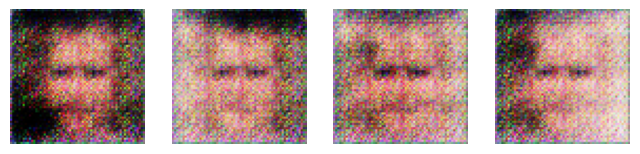

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [6/40], loss_g: 2.9654, loss_d: 0.9382, real_score: 0.6991, fake_score: 0.2775


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [7/40], loss_g: 3.9003, loss_d: 0.6765, real_score: 0.7794, fake_score: 0.1998


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [8/40], loss_g: 3.5799, loss_d: 0.6310, real_score: 0.7988, fake_score: 0.1798


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [9/40], loss_g: 3.5364, loss_d: 0.5681, real_score: 0.8211, fake_score: 0.1828


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [10/40], loss_g: 3.8238, loss_d: 0.7515, real_score: 0.7831, fake_score: 0.2238


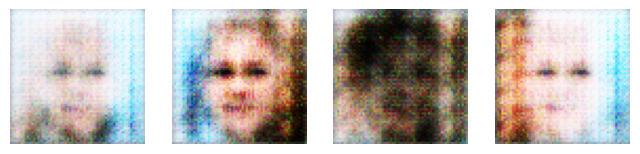

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [11/40], loss_g: 3.4459, loss_d: 0.7593, real_score: 0.7745, fake_score: 0.2420


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [12/40], loss_g: 3.5699, loss_d: 0.6683, real_score: 0.7778, fake_score: 0.2141


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [13/40], loss_g: 3.9685, loss_d: 0.8633, real_score: 0.7487, fake_score: 0.2633


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [14/40], loss_g: 4.0016, loss_d: 0.8327, real_score: 0.7598, fake_score: 0.2454


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [15/40], loss_g: 3.8468, loss_d: 0.7202, real_score: 0.7679, fake_score: 0.2261


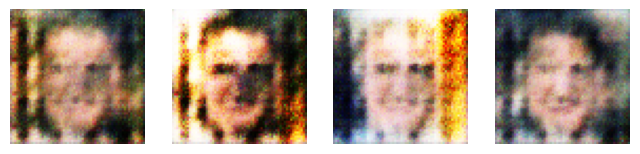

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [16/40], loss_g: 4.4064, loss_d: 0.7028, real_score: 0.7797, fake_score: 0.2123


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [17/40], loss_g: 4.1555, loss_d: 0.8004, real_score: 0.7623, fake_score: 0.2423


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [18/40], loss_g: 4.1876, loss_d: 0.8834, real_score: 0.7345, fake_score: 0.2564


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [19/40], loss_g: 3.8895, loss_d: 0.8045, real_score: 0.7583, fake_score: 0.2373


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [20/40], loss_g: 4.0107, loss_d: 0.6854, real_score: 0.7703, fake_score: 0.2226


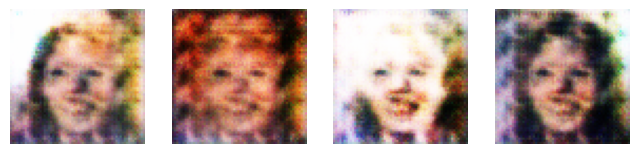

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [21/40], loss_g: 4.2097, loss_d: 0.7743, real_score: 0.7603, fake_score: 0.2371


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [22/40], loss_g: 4.4239, loss_d: 0.7783, real_score: 0.7566, fake_score: 0.2518


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [23/40], loss_g: 4.0794, loss_d: 0.7244, real_score: 0.7576, fake_score: 0.2245


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [24/40], loss_g: 4.2514, loss_d: 0.8304, real_score: 0.7632, fake_score: 0.2522


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [25/40], loss_g: 3.9545, loss_d: 0.7173, real_score: 0.7608, fake_score: 0.2318


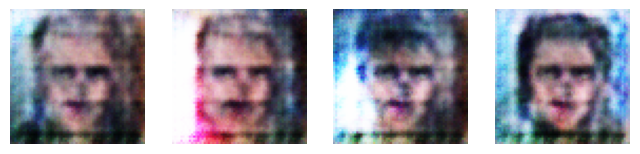

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [26/40], loss_g: 4.2891, loss_d: 0.8020, real_score: 0.7460, fake_score: 0.2480


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [27/40], loss_g: 4.1595, loss_d: 0.8357, real_score: 0.7494, fake_score: 0.2531


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [28/40], loss_g: 3.8615, loss_d: 0.7509, real_score: 0.7481, fake_score: 0.2422


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [29/40], loss_g: 3.6856, loss_d: 0.7659, real_score: 0.7536, fake_score: 0.2437


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [30/40], loss_g: 3.8605, loss_d: 0.8206, real_score: 0.7395, fake_score: 0.2592


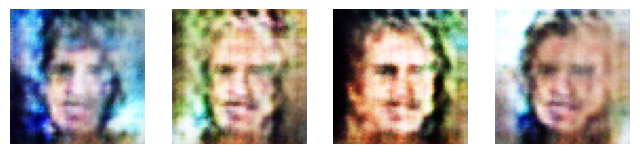

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [31/40], loss_g: 3.8622, loss_d: 0.8157, real_score: 0.7384, fake_score: 0.2479


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [32/40], loss_g: 3.5735, loss_d: 0.6855, real_score: 0.7748, fake_score: 0.2346


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [33/40], loss_g: 3.9158, loss_d: 0.8105, real_score: 0.7412, fake_score: 0.2521


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [34/40], loss_g: 3.5973, loss_d: 0.6704, real_score: 0.7821, fake_score: 0.2270


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [35/40], loss_g: 3.7254, loss_d: 0.6127, real_score: 0.7895, fake_score: 0.1966


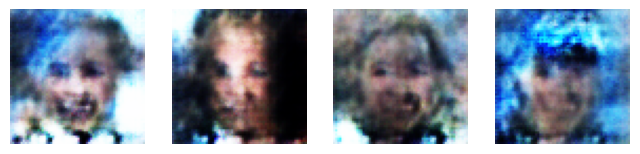

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [36/40], loss_g: 4.2760, loss_d: 0.7558, real_score: 0.7683, fake_score: 0.2318


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [37/40], loss_g: 3.7133, loss_d: 0.7833, real_score: 0.7569, fake_score: 0.2461


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [38/40], loss_g: 3.8200, loss_d: 0.6620, real_score: 0.7829, fake_score: 0.2079


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [39/40], loss_g: 3.8360, loss_d: 0.7067, real_score: 0.7710, fake_score: 0.2244


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [40/40], loss_g: 3.8494, loss_d: 0.7186, real_score: 0.7778, fake_score: 0.2249


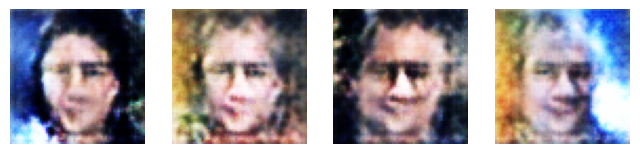

In [75]:
losses_g, losses_d, real_scores, fake_scores = fit(model, criterion, 40, lr)

In [76]:
torch.save(model['discriminator'].cpu().state_dict(), 'disc_5')
torch.save(model['generator'].cpu().state_dict(), 'gen_5')
model['discriminator'].to(device)
model['generator'].to(device)

Sequential(
  (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (13): Tanh()
)

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

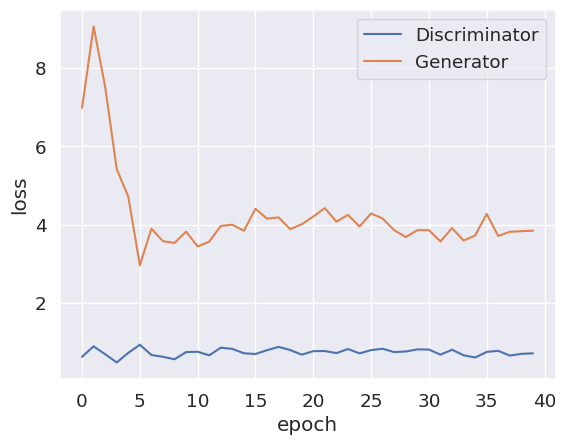

In [77]:
plt.plot(losses_d)
plt.plot(losses_g)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.show()

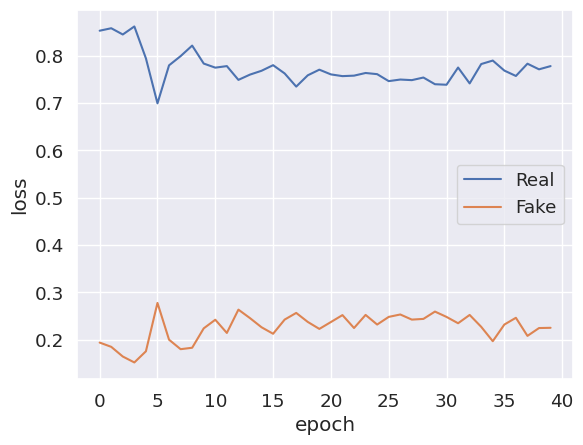

In [78]:
plt.plot(real_scores)
plt.plot(fake_scores)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Real', 'Fake'])
plt.show()

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [1/100], loss_g: 6.4466, loss_d: 0.4594, real_score: 0.9337, fake_score: 0.1279


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [2/100], loss_g: 8.3054, loss_d: 0.4230, real_score: 0.9389, fake_score: 0.0794


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [3/100], loss_g: 7.6204, loss_d: 0.3812, real_score: 0.9427, fake_score: 0.0754


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [4/100], loss_g: 7.6799, loss_d: 0.3879, real_score: 0.9378, fake_score: 0.0465


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [5/100], loss_g: 6.4252, loss_d: 0.6622, real_score: 0.9026, fake_score: 0.0842


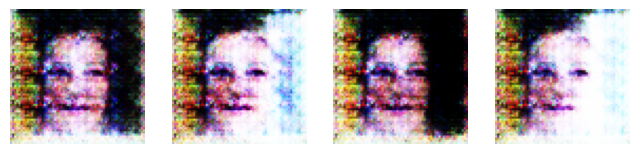

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [6/100], loss_g: 5.4065, loss_d: 0.6327, real_score: 0.8951, fake_score: 0.1267


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [7/100], loss_g: 3.9980, loss_d: 0.3763, real_score: 0.8976, fake_score: 0.1053


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [8/100], loss_g: 4.6192, loss_d: 0.3527, real_score: 0.9118, fake_score: 0.0833


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [9/100], loss_g: 5.4969, loss_d: 0.4934, real_score: 0.8694, fake_score: 0.1164


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [10/100], loss_g: 4.9633, loss_d: 0.5467, real_score: 0.8450, fake_score: 0.1491


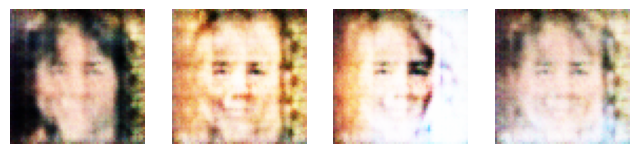

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [11/100], loss_g: 4.7621, loss_d: 0.4152, real_score: 0.8774, fake_score: 0.1178


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [12/100], loss_g: 5.2819, loss_d: 0.5340, real_score: 0.8586, fake_score: 0.1393


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [13/100], loss_g: 4.3310, loss_d: 0.3647, real_score: 0.9001, fake_score: 0.1032


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [14/100], loss_g: 4.9273, loss_d: 0.3905, real_score: 0.8899, fake_score: 0.1013


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [15/100], loss_g: 5.1328, loss_d: 0.3766, real_score: 0.8964, fake_score: 0.1002


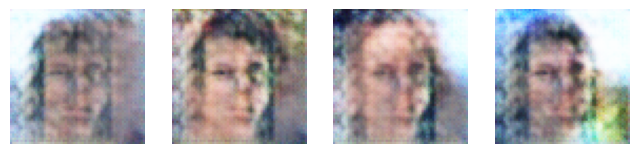

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [16/100], loss_g: 5.5525, loss_d: 0.6207, real_score: 0.8491, fake_score: 0.1469


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [17/100], loss_g: 5.2003, loss_d: 0.4684, real_score: 0.8712, fake_score: 0.1271


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [18/100], loss_g: 5.0203, loss_d: 0.3927, real_score: 0.8966, fake_score: 0.1068


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [19/100], loss_g: 4.3339, loss_d: 0.3756, real_score: 0.8970, fake_score: 0.0984


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [20/100], loss_g: 4.6126, loss_d: 0.4011, real_score: 0.8912, fake_score: 0.1056


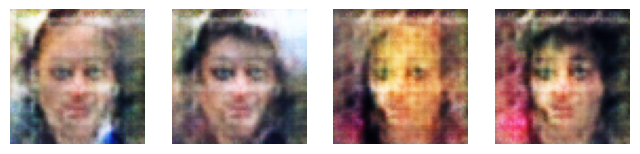

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [21/100], loss_g: 5.0789, loss_d: 0.4081, real_score: 0.8988, fake_score: 0.1062


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [22/100], loss_g: 4.9976, loss_d: 0.4174, real_score: 0.8912, fake_score: 0.1004


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [23/100], loss_g: 4.9628, loss_d: 0.4204, real_score: 0.8881, fake_score: 0.1087


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [24/100], loss_g: 4.3466, loss_d: 0.3937, real_score: 0.8992, fake_score: 0.1013


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [25/100], loss_g: 5.2954, loss_d: 0.4655, real_score: 0.8777, fake_score: 0.1129


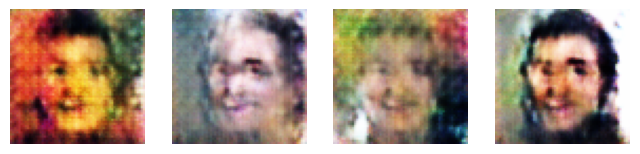

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [26/100], loss_g: 4.7722, loss_d: 0.5724, real_score: 0.8700, fake_score: 0.1419


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [27/100], loss_g: 4.9787, loss_d: 0.5207, real_score: 0.8630, fake_score: 0.1338


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [28/100], loss_g: 4.3982, loss_d: 0.4410, real_score: 0.8736, fake_score: 0.1229


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [29/100], loss_g: 4.5449, loss_d: 0.3701, real_score: 0.9029, fake_score: 0.0986


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [30/100], loss_g: 5.2195, loss_d: 0.4167, real_score: 0.8950, fake_score: 0.1137


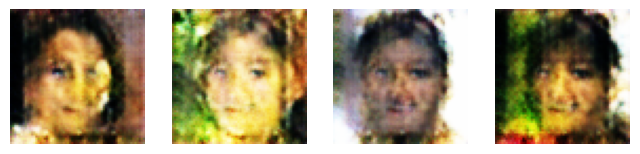

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [31/100], loss_g: 5.2264, loss_d: 0.6027, real_score: 0.8565, fake_score: 0.1353


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [32/100], loss_g: 4.6171, loss_d: 0.4270, real_score: 0.8840, fake_score: 0.1129


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [33/100], loss_g: 4.8475, loss_d: 0.4856, real_score: 0.8696, fake_score: 0.1247


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [34/100], loss_g: 4.2680, loss_d: 0.3854, real_score: 0.9013, fake_score: 0.1003


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [35/100], loss_g: 4.5531, loss_d: 0.3916, real_score: 0.8976, fake_score: 0.1079


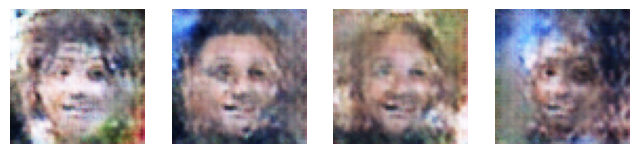

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [36/100], loss_g: 5.3636, loss_d: 0.6673, real_score: 0.8352, fake_score: 0.1636


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [37/100], loss_g: 4.6969, loss_d: 0.4515, real_score: 0.8741, fake_score: 0.1213


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [38/100], loss_g: 5.0484, loss_d: 0.4790, real_score: 0.8733, fake_score: 0.1238


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [39/100], loss_g: 4.1424, loss_d: 0.3747, real_score: 0.8913, fake_score: 0.1025


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [40/100], loss_g: 4.9429, loss_d: 0.4897, real_score: 0.8743, fake_score: 0.1280


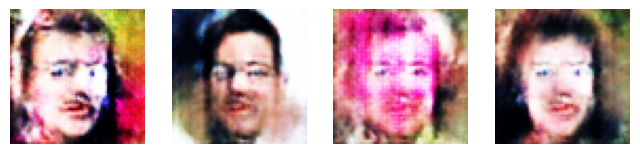

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [41/100], loss_g: 4.5270, loss_d: 0.4321, real_score: 0.8756, fake_score: 0.1127


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [42/100], loss_g: 4.5843, loss_d: 0.4673, real_score: 0.8848, fake_score: 0.1267


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [43/100], loss_g: 4.5509, loss_d: 0.4142, real_score: 0.8834, fake_score: 0.1056


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [44/100], loss_g: 4.5519, loss_d: 0.4259, real_score: 0.8920, fake_score: 0.1169


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [45/100], loss_g: 4.4950, loss_d: 0.4323, real_score: 0.8850, fake_score: 0.1164


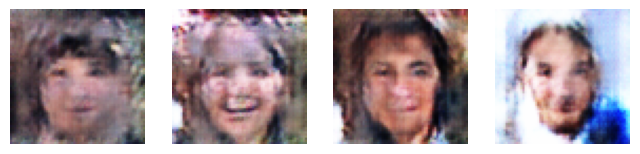

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [46/100], loss_g: 5.0527, loss_d: 0.5474, real_score: 0.8519, fake_score: 0.1372


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [47/100], loss_g: 4.7701, loss_d: 0.4652, real_score: 0.8709, fake_score: 0.1327


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [48/100], loss_g: 4.5109, loss_d: 0.3891, real_score: 0.8944, fake_score: 0.1008


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [49/100], loss_g: 4.6700, loss_d: 0.4783, real_score: 0.8729, fake_score: 0.1281


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [50/100], loss_g: 4.3408, loss_d: 0.3939, real_score: 0.8883, fake_score: 0.1065


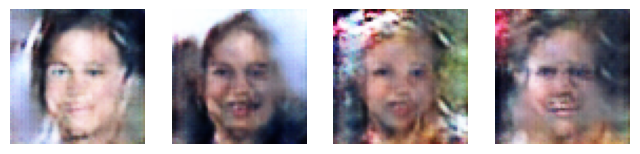

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [51/100], loss_g: 4.4338, loss_d: 0.4811, real_score: 0.8721, fake_score: 0.1244


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [52/100], loss_g: 5.3735, loss_d: 0.7830, real_score: 0.8159, fake_score: 0.1951


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [53/100], loss_g: 4.8394, loss_d: 0.6386, real_score: 0.8185, fake_score: 0.1696


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [54/100], loss_g: 4.4281, loss_d: 0.5571, real_score: 0.8486, fake_score: 0.1559


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [55/100], loss_g: 3.9104, loss_d: 0.4047, real_score: 0.8751, fake_score: 0.1141


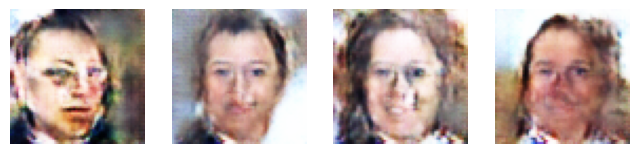

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [56/100], loss_g: 4.0168, loss_d: 0.4105, real_score: 0.8829, fake_score: 0.1219


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [57/100], loss_g: 3.8723, loss_d: 0.3909, real_score: 0.8867, fake_score: 0.1068


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [58/100], loss_g: 4.1669, loss_d: 0.3708, real_score: 0.9040, fake_score: 0.1031


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [59/100], loss_g: 4.8046, loss_d: 0.4358, real_score: 0.8833, fake_score: 0.1195


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [60/100], loss_g: 5.4343, loss_d: 0.8330, real_score: 0.8102, fake_score: 0.1927


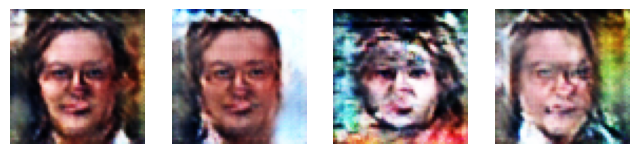

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [61/100], loss_g: 4.7224, loss_d: 0.5494, real_score: 0.8416, fake_score: 0.1510


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [62/100], loss_g: 3.8797, loss_d: 0.3999, real_score: 0.8823, fake_score: 0.1190


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [63/100], loss_g: 3.9114, loss_d: 0.3622, real_score: 0.8958, fake_score: 0.1008


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [64/100], loss_g: 4.0741, loss_d: 0.3784, real_score: 0.8942, fake_score: 0.1036


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [65/100], loss_g: 4.5921, loss_d: 0.5435, real_score: 0.8626, fake_score: 0.1399


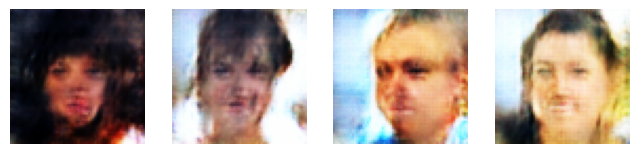

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [66/100], loss_g: 4.0555, loss_d: 0.3900, real_score: 0.8883, fake_score: 0.1063


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [67/100], loss_g: 4.2860, loss_d: 0.3671, real_score: 0.9008, fake_score: 0.0999


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [68/100], loss_g: 4.6420, loss_d: 0.4547, real_score: 0.8807, fake_score: 0.1193


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [69/100], loss_g: 4.8669, loss_d: 0.5671, real_score: 0.8546, fake_score: 0.1451


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [70/100], loss_g: 4.0736, loss_d: 0.4072, real_score: 0.8867, fake_score: 0.1073


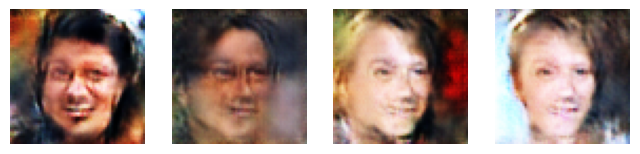

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [71/100], loss_g: 3.7739, loss_d: 0.3560, real_score: 0.9018, fake_score: 0.0968


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [72/100], loss_g: 3.8234, loss_d: 0.3365, real_score: 0.9136, fake_score: 0.0897


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [73/100], loss_g: 4.4362, loss_d: 0.6924, real_score: 0.8381, fake_score: 0.1570


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [74/100], loss_g: 4.9888, loss_d: 0.6453, real_score: 0.8275, fake_score: 0.1755


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [75/100], loss_g: 4.5560, loss_d: 0.4127, real_score: 0.8818, fake_score: 0.1208


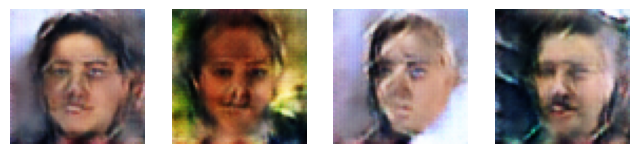

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [76/100], loss_g: 3.8629, loss_d: 0.3984, real_score: 0.8852, fake_score: 0.1086


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [77/100], loss_g: 3.8933, loss_d: 0.3785, real_score: 0.8932, fake_score: 0.1021


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [78/100], loss_g: 4.8804, loss_d: 0.7628, real_score: 0.8231, fake_score: 0.1907


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [79/100], loss_g: 4.6147, loss_d: 0.4811, real_score: 0.8636, fake_score: 0.1267


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [80/100], loss_g: 3.9388, loss_d: 0.3736, real_score: 0.8960, fake_score: 0.1053


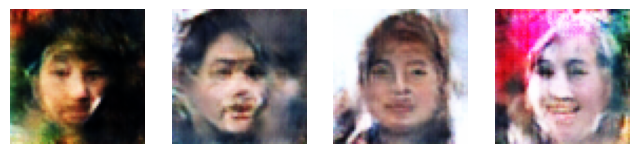

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [81/100], loss_g: 4.2157, loss_d: 0.3968, real_score: 0.8929, fake_score: 0.1031


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [82/100], loss_g: 3.7916, loss_d: 0.3827, real_score: 0.8943, fake_score: 0.1054


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [83/100], loss_g: 3.7602, loss_d: 0.3457, real_score: 0.9057, fake_score: 0.0934


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [84/100], loss_g: 4.5190, loss_d: 0.6016, real_score: 0.8417, fake_score: 0.1572


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [85/100], loss_g: 4.1448, loss_d: 0.4095, real_score: 0.8845, fake_score: 0.1165


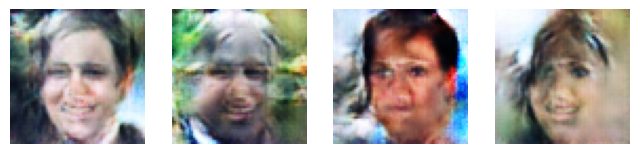

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [86/100], loss_g: 3.7782, loss_d: 0.3650, real_score: 0.8980, fake_score: 0.0987


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [87/100], loss_g: 4.8511, loss_d: 0.7474, real_score: 0.8162, fake_score: 0.1789


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [88/100], loss_g: 4.0853, loss_d: 0.4397, real_score: 0.8756, fake_score: 0.1279


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [89/100], loss_g: 3.8507, loss_d: 0.3544, real_score: 0.9043, fake_score: 0.0974


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [90/100], loss_g: 3.7759, loss_d: 0.3537, real_score: 0.9051, fake_score: 0.0939


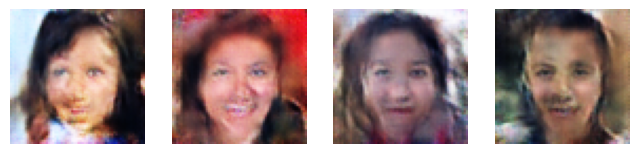

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [91/100], loss_g: 4.6373, loss_d: 0.8214, real_score: 0.8069, fake_score: 0.1930


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [92/100], loss_g: 4.6967, loss_d: 0.5258, real_score: 0.8549, fake_score: 0.1494


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [93/100], loss_g: 3.8373, loss_d: 0.3929, real_score: 0.8856, fake_score: 0.1076


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [94/100], loss_g: 3.7908, loss_d: 0.3573, real_score: 0.9012, fake_score: 0.0958


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [95/100], loss_g: 3.7178, loss_d: 0.3423, real_score: 0.9078, fake_score: 0.0903


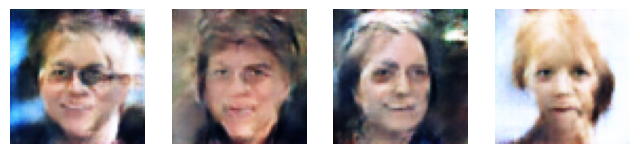

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [96/100], loss_g: 3.8332, loss_d: 0.3443, real_score: 0.9113, fake_score: 0.0886


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [97/100], loss_g: 3.8400, loss_d: 0.3448, real_score: 0.9135, fake_score: 0.0908


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [98/100], loss_g: 3.8811, loss_d: 0.3505, real_score: 0.9062, fake_score: 0.0871


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [99/100], loss_g: 3.9770, loss_d: 0.3682, real_score: 0.9042, fake_score: 0.0966


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [100/100], loss_g: 4.2803, loss_d: 1.0024, real_score: 0.8125, fake_score: 0.2015


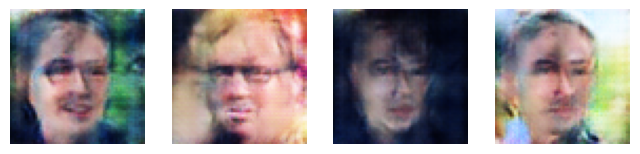

In [79]:
losses_g, losses_d, real_scores, fake_scores = fit(model, criterion, 100, lr)

In [98]:
torch.save(model['discriminator'].cpu().state_dict(), 'disc_6')
torch.save(model['generator'].cpu().state_dict(), 'gen_6')
model['discriminator'].to(device)
model['generator'].to(device)

Sequential(
  (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (13): Tanh()
)

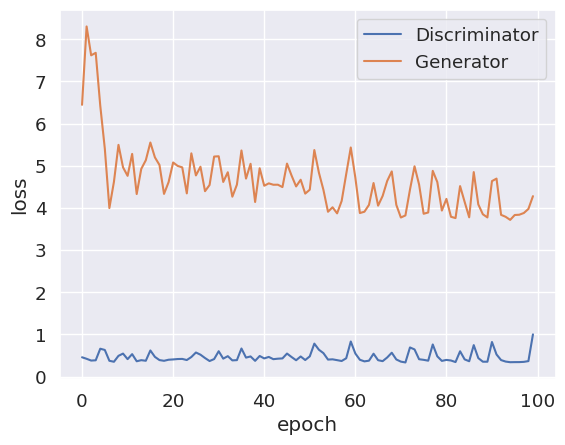

In [82]:
plt.plot(losses_d)
plt.plot(losses_g)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.show()

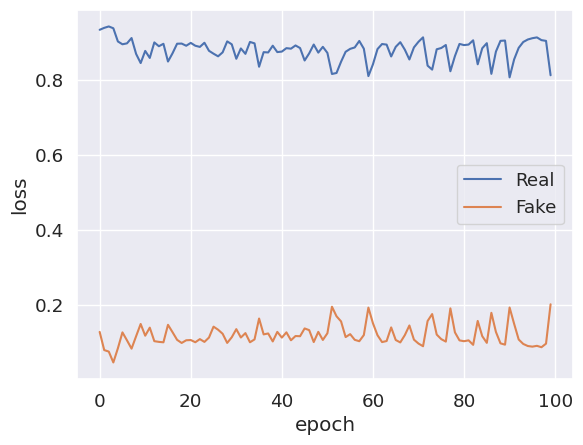

In [83]:
plt.plot(real_scores)
plt.plot(fake_scores)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Real', 'Fake'])
plt.show()

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [80]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

In [81]:
def show_images(generated):
  generated = denorm(generated.detach().cpu().permute(0, 2, 3, 1).numpy())
  n = generated.shape[0]

  _, axes = plt.subplots(1, n, figsize=(3 * n, 3))
  for i in range(n):
    axes[i].imshow(generated[i])
    axes[i].axis('off')

  plt.show()

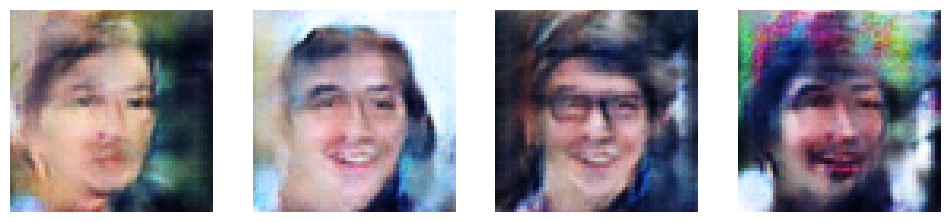

In [84]:
show_images(fake_images)

Как вам качество получившихся изображений?

Ну как дети инцеста с долгой истории семьи, качество примерно такое. По лоссу генератора можно увидеть что он застрял между 4 и 5 и не обучался дальше, с лоссом дискрименатора все ок.

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [104]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut

def knn_acc(real_images, fake_images):
  real_images = real_images.view(real_images.size(0), -1).cpu().detach().numpy()
  fake_images = fake_images.view(fake_images.size(0), -1).cpu().detach().numpy()

  n_real = real_images.shape[0]
  n_fake = fake_images.shape[0]

  X = np.concatenate([real_images, fake_images], axis=0)
  y = np.concatenate([np.ones(n_real), np.zeros(n_fake)])

  splitter = LeaveOneOut()
  correct = 0

  for train_index, test_index in splitter.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    if y_pred == y_test:
      correct += 1

  accuracy = correct / (n_real + n_fake)
  return accuracy

In [102]:
batch_count = 4
real_images = []
batch_i = 0
for batch, _ in dataloader:
  batch = batch.to(device)
  real_images.append(batch)
  batch_i += 1
  if batch_i == batch_count:
    break
real_images = torch.cat(real_images, dim=0).to(device)

model["generator"].eval()
with torch.no_grad():
  latent = torch.randn(batch_count * batch_size, latent_size, 1, 1, device=device)
  fake_images = model["generator"](latent)

In [105]:
accuracy = knn_acc(real_images, fake_images)
print(f"Leave-One-Out Accuracy: {accuracy:.4f}")

Leave-One-Out Accuracy: 0.6367


в целом генератор не так плохо работает, так как если бы аккураси был бы 0.5 это значило бы что генератор делает реалистичные лица, у нас этого нет, так что имеем что имеем. у нас где то посередине по сути, так как если 1 аккураси, то значит лица легко различимы и это плохо

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

In [106]:
from sklearn.manifold import TSNE

real_images_flatten = real_images.view(real_images.size(0), -1).cpu().detach().numpy()
fake_images_flatten = fake_images.view(fake_images.size(0), -1).cpu().detach().numpy()

n_real = real_images_flatten.shape[0]
n_fake = fake_images_flatten.shape[0]

images = np.concatenate([real_images_flatten, fake_images_flatten], axis=0)
labels = np.concatenate([np.ones(n_real), np.zeros(n_fake)])

tsne = TSNE(n_components=2, random_state=42)
images_2d = tsne.fit_transform(images)

Прокомментируйте получившийся результат:

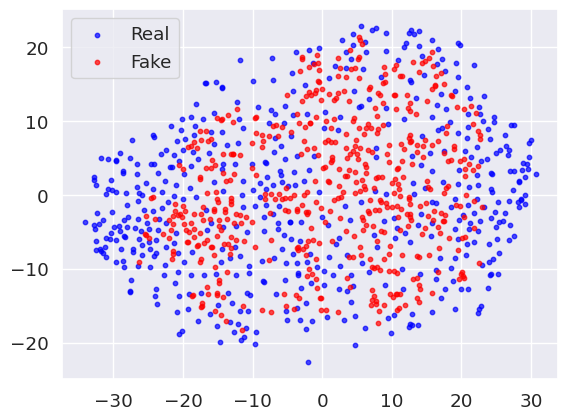

In [107]:
plt.scatter(
    images_2d[labels == 1, 0], images_2d[labels == 1, 1],
    label="Real", alpha=0.7, c='blue', s=10
)
plt.scatter(
    images_2d[labels == 0, 0], images_2d[labels == 0, 1],
    label="Fake", alpha=0.7, c='red', s=10
)
plt.legend()
plt.show()

Ну по сути мы можем увидеть что точки что рил что фейка в одной группе находятся. Но мне кажется что качество генерации по этому не определить